In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

In [3]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

100%|██████████| 26.4M/26.4M [00:10<00:00, 2.57MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 683kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 9.40MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 79.1MB/s]


Matplotlib is building the font cache; this may take a moment.


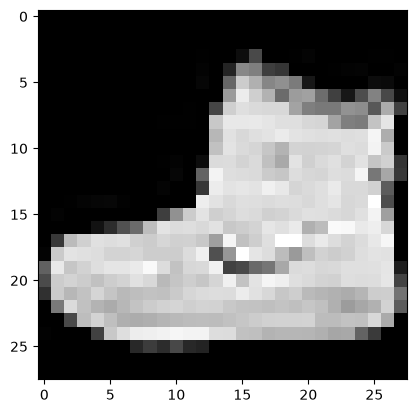

In [5]:
# visiualize an image   
import matplotlib.pyplot as plt
plt.imshow(training_data[0][0].squeeze(), cmap="gray")
plt.show()



In [6]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [20]:
def show_data(data):
    plt.imshow(data[0][0].squeeze(), cmap="gray")
    plt.show()

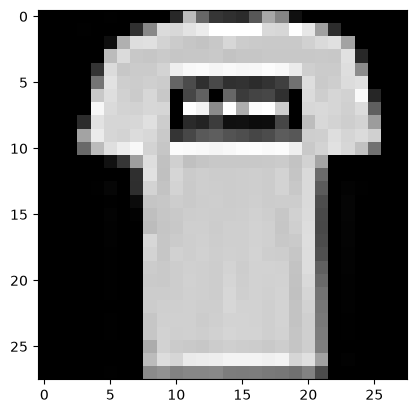

In [22]:
show_data(training_data[1])

In [25]:
training_data[0][1]

9

In [28]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [30]:

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() #28x28 image to 784 vector
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [31]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [37]:
# count the number of parameters in the model
num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in the model: {num_params}")

Number of parameters in the model: 669706


In [36]:
torch.max(torch.softmax(model(training_data[0][0].to(device)), dim=1), dim=1)

torch.return_types.max(
values=tensor([0.1079], device='mps:0', grad_fn=<MaxBackward0>),
indices=tensor([7], device='mps:0'))

In [ ]:
loss_fn = nn.CrossEntropyLoss() # hatayi hesaplamak icin loss function
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3) # backpropagation icin optimizer, lr = learning rate 0.001 kadar duzelt

In [40]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [41]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [46]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.793795  [   64/60000]
loss: 0.868714  [ 6464/60000]
loss: 0.640173  [12864/60000]
loss: 0.843771  [19264/60000]
loss: 0.740707  [25664/60000]
loss: 0.740703  [32064/60000]
loss: 0.825276  [38464/60000]
loss: 0.805703  [44864/60000]
loss: 0.792210  [51264/60000]
loss: 0.767870  [57664/60000]
Test Error: 
 Accuracy: 71.3%, Avg loss: 0.764549 

Epoch 2
-------------------------------
loss: 0.755688  [   64/60000]
loss: 0.838413  [ 6464/60000]
loss: 0.608889  [12864/60000]
loss: 0.818585  [19264/60000]
loss: 0.719567  [25664/60000]
loss: 0.715819  [32064/60000]
loss: 0.800326  [38464/60000]
loss: 0.789475  [44864/60000]
loss: 0.770336  [51264/60000]
loss: 0.746411  [57664/60000]
Test Error: 
 Accuracy: 72.6%, Avg loss: 0.742474 

Epoch 3
-------------------------------
loss: 0.722261  [   64/60000]
loss: 0.811169  [ 6464/60000]
loss: 0.582253  [12864/60000]
loss: 0.797204  [19264/60000]
loss: 0.701355  [25664/60000]
loss: 0.695250  [32064/600

In [47]:
torch.max(torch.softmax(model(training_data[0][0].to(device)), dim=1), dim=1)

torch.return_types.max(
values=tensor([0.9010], device='mps:0', grad_fn=<MaxBackward0>),
indices=tensor([9], device='mps:0'))

In [48]:
test(train_dataloader, model, loss_fn=loss_fn)

Test Error: 
 Accuracy: 76.6%, Avg loss: 0.672104 



In [57]:
# Test Model
class TestNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() #28x28 image to 784 vector
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(784, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

test_model = TestNeuralNetwork().to(device)
print(test_model)

TestNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=10, bias=True)
  )
)


In [58]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, test_model, loss_fn, optimizer)
    test(test_dataloader, test_model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.384179  [   64/60000]
loss: 2.357959  [ 6464/60000]
loss: 2.350107  [12864/60000]
loss: 2.376402  [19264/60000]
loss: 2.359801  [25664/60000]
loss: 2.400795  [32064/60000]
loss: 2.361962  [38464/60000]
loss: 2.415065  [44864/60000]
loss: 2.412732  [51264/60000]
loss: 2.417294  [57664/60000]
Test Error: 
 Accuracy: 2.5%, Avg loss: 2.397207 

Epoch 2
-------------------------------
loss: 2.384179  [   64/60000]
loss: 2.357959  [ 6464/60000]
loss: 2.350107  [12864/60000]
loss: 2.376402  [19264/60000]
loss: 2.359801  [25664/60000]
loss: 2.400795  [32064/60000]
loss: 2.361962  [38464/60000]
loss: 2.415065  [44864/60000]
loss: 2.412732  [51264/60000]
loss: 2.417294  [57664/60000]
Test Error: 
 Accuracy: 2.5%, Avg loss: 2.397207 

Epoch 3
-------------------------------
loss: 2.384179  [   64/60000]
loss: 2.357959  [ 6464/60000]
loss: 2.350107  [12864/60000]
loss: 2.376402  [19264/60000]
loss: 2.359801  [25664/60000]
loss: 2.400795  [32064/60000

In [54]:
num_params = sum(p.numel() for p in test_model.parameters())
print(f"Number of parameters in the model: {num_params}")

Number of parameters in the model: 7850


In [56]:
test(train_dataloader, test_model, loss_fn=loss_fn)

Test Error: 
 Accuracy: 2.5%, Avg loss: 2.396699 

